# Simple Grid World: Policy Approximation

## Installation and Setup

You need:
* Gymnasium (see [Installation Instructions](../common/Setup_Gymnasium.ipynb))
* Patched `gym-classics-1.0.0+internal.rev1` or later (see [Installation instructions](../common/Setup_patched_gym_classics.ipynb))

In [280]:
import numpy as np
np.set_printoptions(precision=2)

In [281]:
import gymnasium as gym
import gym_classics
gym_classics.register('gymnasium')

/home/mhahsler/github/Introduction_to_Reinforcement_Learning/common/gym-classics/gym_classics/__init__.py:87: UserWarning: gym-classics environments were already registered for gymnasium; additional calls to `register()` are ignored.
  warnings.warn("gym-classics environments were already registered for {}; "


## Define the L-Maze Grid World 

In [282]:
gym_env = gym.make('LMaze-v0')
env = gym_env.unwrapped

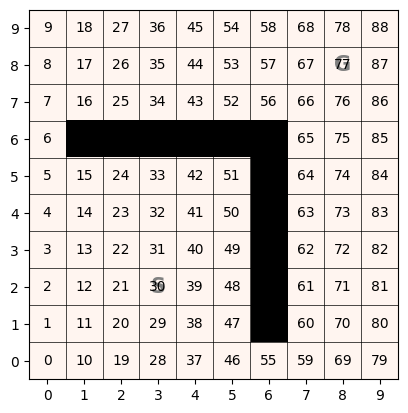

In [283]:
env.image()

## Policy Approximation: Linear Soft-Max In Action Preferences

Use Fourier-basis transformation and set up state-action features.

In [284]:
from gym_classics.algorithms.linear_approximation import transformation_fourier_basis, active_weights

trans_fb = transformation_fourier_basis(min = np.array([0,0]), max = env.dims, order=2)

def state_features(s,env):
    return trans_fb(env.decode(s))

In [285]:
def state_action_features(s,a,env):
    s = state_features(s,env)
    x = np.zeros(1+len(s)*env.action_space.n)
    x[active_weights(a, len(s)-1)] = s
    return x

Define the preference function $h(s,a,\bf{\theta})=\bf{\theta}^\top \bf{x}(s,a)$

In [286]:
def h(s,a,theta,env):
    return np.dot(theta, state_action_features(s,a,env))

Soft-max transformation from scores to a probability distribution: $\pi(s,a,\theta) = \frac{e^{h(s,a,\bf{\theta})}}{\sum_b h(s,a,\bf{\theta})}$

In [287]:
def pi(s,theta,env):
    hs = np.array([h(s,a,theta,env) for a in range(env.action_space.n)])
    exp_hs = np.exp(hs)
    return exp_hs / np.sum(exp_hs)

Check with a random weight vector.

In [288]:
theta = np.random.rand(1+len(state_features(0, env))*env.action_space.n)
theta

array([0.46, 0.38, 0.8 , 0.21, 0.4 , 0.29, 0.07, 0.93, 0.58, 0.34, 0.18,
       0.6 , 0.25, 0.56, 1.  , 0.59, 0.89, 0.41, 0.58, 0.56, 0.64, 0.97,
       0.5 , 0.25, 0.18, 0.71, 0.32, 0.45, 0.78, 0.77, 0.17, 0.01, 0.9 ,
       0.34, 0.04, 0.55, 0.85])

Calculate the preferences score for all actions for state 0.

In [289]:
[h(0,a,theta, env) for a in range(env.action_space.n)] 

[np.float64(4.13197585533039),
 np.float64(4.863814373692087),
 np.float64(4.5618353448103495),
 np.float64(4.571031437365227)]

Calculate $\pi(s,a,\theta)$ for all actions in state $s=0$

In [290]:
pi(0,theta,env)

array([0.16, 0.34, 0.25, 0.25])

## REINFORCE

![Pseudocode REINFORCE](https://raw.githubusercontent.com/mhahsler/Introduction_to_Reinforcement_Learning/refs/heads/main/figures/RL-Intro_REINFORCE.png)

We need to sample following a stochastic policy.

In [291]:
def sample_episode_policy(env, pi, theta, max_episode_length=1000):
    """
    Sample an episode using the policy defined by pi and theta.
    Returns a list of (state, action, reward) tuples.
    """
    s, _ = env.reset()
    episode_data = []
    
    for t in range(max_episode_length):
        a = np.random.choice(range(env.action_space.n), p=pi(s,theta,env))
        next_s, r, done, _, _ = env.step(a)
        episode_data.append((s, a, r, next_s))
        s = next_s
        
        if done:
            break
    
    return episode_data


In [292]:
episode_data = sample_episode_policy(env, pi, theta)
episode_data

[(30, np.int64(2), 0.0, 29),
 (29, np.int64(1), 0.0, 38),
 (38, np.int64(0), 0.0, 39),
 (39, np.int64(2), 0.0, 38),
 (38, np.int64(2), 0.0, 37),
 (37, np.int64(2), 0.0, 37),
 (37, np.int64(3), 0.0, 28),
 (28, np.int64(2), 0.0, 28),
 (28, np.int64(3), 0.0, 19),
 (19, np.int64(3), 0.0, 10),
 (10, np.int64(3), 0.0, 0),
 (0, np.int64(0), 0.0, 1),
 (1, np.int64(0), 0.0, 2),
 (2, np.int64(3), 0.0, 2),
 (2, np.int64(1), 0.0, 12),
 (12, np.int64(3), 0.0, 2),
 (2, np.int64(1), 0.0, 12),
 (12, np.int64(2), 0.0, 11),
 (11, np.int64(3), 0.0, 1),
 (1, np.int64(3), 0.0, 1),
 (1, np.int64(1), 0.0, 11),
 (11, np.int64(1), 0.0, 20),
 (20, np.int64(2), 0.0, 19),
 (19, np.int64(1), 0.0, 28),
 (28, np.int64(2), 0.0, 28),
 (28, np.int64(0), 0.0, 29),
 (29, np.int64(1), 0.0, 38),
 (38, np.int64(2), 0.0, 37),
 (37, np.int64(3), 0.0, 28),
 (28, np.int64(2), 0.0, 28),
 (28, np.int64(3), 0.0, 19),
 (19, np.int64(0), 0.0, 20),
 (20, np.int64(3), 0.0, 11),
 (11, np.int64(1), 0.0, 20),
 (20, np.int64(2), 0.0, 19),

Implement the REINFORCE algorithm. The gradient of the policy for linear approximation is proportional to  $\nabla ln\ \pi(s,a,\bf{\theta}) =   \bf{x}(s,a) - \sum_b \pi(b|s,\bf{\theta}) \bf{x}(s,b)$

In [293]:
from tqdm import tqdm

def REINFORCE(
    env,
    n,
    alpha,
    gamma,
    theta = None,
    max_episode_length=1000,
    verbose=False
    ):
    
    if theta is None:
        theta = np.zeros(1+len(state_features(0, env))*env.action_space.n)
        
    for episode in tqdm(range(n), desc="Episodes", disable=verbose):
        if verbose:
            print(f"Episode {episode+1}/{n}")
        
        episode_data = sample_episode_policy(env, pi, theta, max_episode_length)
        
        for t in range(len(episode_data)):
            #print(episode_data[t])
        
            G = np.sum([e[2] for e in episode_data[t:]] * (gamma ** np.arange(len(episode_data[t:]))))

            s,a,r,next_s = episode_data[t]
            
            # ln policy gradient= x(s,a)- sum_b pi(b|s,theta) x(s,b)
            grad_log_pi = state_action_features(s, a, env) - sum([pi(s, theta, env)[b] * state_action_features(s, b, env) for b in range(env.action_space.n)])
            
            if verbose: 
                print (f"t: {t}, G: {G:.2f}, grad_log_pi: {grad_log_pi}")
            
            theta += alpha * (gamma**t) * G * grad_log_pi      
    return theta

In [294]:
theta = REINFORCE(env, n=500, alpha=0.1, gamma=0.99)
theta

Episodes: 100%|██████████| 500/500 [00:03<00:00, 136.14it/s]


array([ 9.47e-15,  1.02e+00, -1.46e+00, -1.74e+00, -1.31e+00,  1.00e+00,
        2.31e+00,  1.54e+00,  3.56e-01,  6.98e-01,  2.60e+00,  7.47e-01,
        9.40e-01,  2.41e+00, -1.39e+00,  7.61e-01, -1.10e+00, -6.95e-01,
       -1.56e+00,  1.42e+00, -7.09e-01, -2.52e+00, -2.31e+00, -1.66e+00,
       -8.83e-01, -1.02e+00,  4.22e-01, -4.22e-01,  1.08e+00, -8.88e-01,
        1.39e+00, -6.37e-01,  1.63e+00,  0.00e+00,  0.00e+00,  0.00e+00,
        0.00e+00])

## The Learned Policy

In [295]:
pol = [pi(s, theta,env) for s in range(env.observation_space.n)]
pol

[array([1.87e-02, 9.65e-01, 4.49e-07, 1.60e-02]),
 array([4.08e-02, 9.29e-01, 3.07e-06, 3.01e-02]),
 array([2.43e-01, 6.33e-01, 3.84e-04, 1.23e-01]),
 array([0.62, 0.11, 0.05, 0.22]),
 array([0.22, 0.  , 0.7 , 0.07]),
 array([3.17e-02, 1.72e-04, 9.55e-01, 1.35e-02]),
 array([2.13e-02, 1.73e-04, 9.58e-01, 2.02e-02]),
 array([0.06, 0.  , 0.77, 0.17]),
 array([0.08, 0.03, 0.13, 0.76]),
 array([0.04, 0.09, 0.01, 0.86]),
 array([8.25e-03, 9.83e-01, 1.11e-06, 9.17e-03]),
 array([1.62e-02, 9.67e-01, 3.00e-05, 1.68e-02]),
 array([0.12, 0.78, 0.01, 0.09]),
 array([0.15, 0.05, 0.7 , 0.1 ]),
 array([1.20e-02, 3.13e-04, 9.80e-01, 7.76e-03]),
 array([4.39e-03, 2.73e-05, 9.91e-01, 4.15e-03]),
 array([0.05, 0.  , 0.65, 0.29]),
 array([0.06, 0.03, 0.08, 0.83]),
 array([0.04, 0.14, 0.01, 0.82]),
 array([1.03e-03, 9.97e-01, 1.24e-05, 2.19e-03]),
 array([2.32e-03, 9.92e-01, 9.13e-04, 5.15e-03]),
 array([0.02, 0.61, 0.34, 0.03]),
 array([0.  , 0.  , 0.99, 0.  ]),
 array([4.94e-04, 2.99e-05, 9.99e-01, 8.26

Visualize the learned policy by showing the action with the highest probability. The probability is shown using the tile color. 
Closer to 1 means that the algorithm is more sure about the action. Smaller values means that the algorithms still would like to explore.

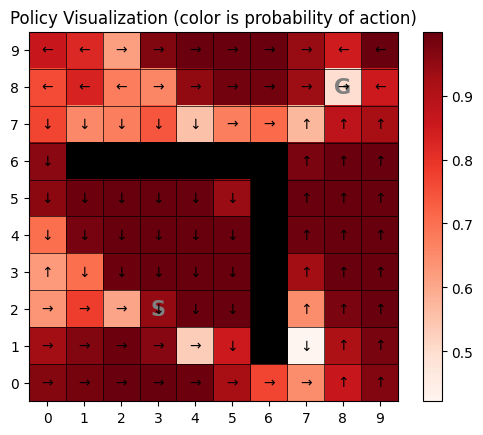

In [296]:
pol_discrete = np.argmax(pol, axis=1)
prob = np.max(pol, axis=1)
env.image(V=prob, policy=pol_discrete, title="Policy Visualization (color is probability of action)")

Visualize the found path using the highest probability action.

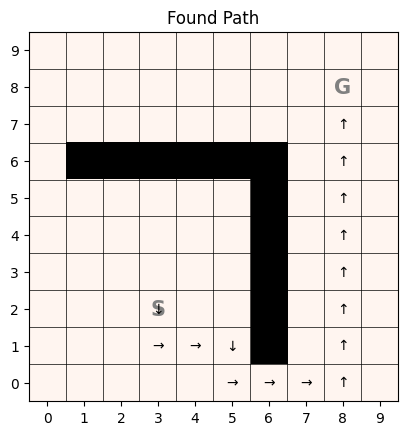

In [298]:
from gym_classics.algorithms.monte_carlo_methods import sample_episode

path = sample_episode(env, policy=pol_discrete, max_len=100)
env.image(policy=pol_discrete, episode=path, title='Found Path')


&copy; 2025 [Michael Hahsler](http://michael.hahsler.net). 
This work is openly licensed under [Creative Commons Attribution-ShareAlike 4.0 International (CC BY-SA 4.0) License](https://creativecommons.org/licenses/by-sa/4.0/)

![CC BY-SA 4.0](https://licensebuttons.net/l/by-sa/3.0/88x31.png)